# Machine Learning Pipelines Lab

## Modeling Retail Product Returns

You've been hired as a data scientist at a major retail company that wants to predict which products will be returned based on product characteristics and customer behavior. Product returns are costly to the business in terms of logistics, restocking, and customer satisfaction. The company wants to identify potentially high-return products early in their lifecycle so they can improve product descriptions, adjust marketing, or even reconsider stocking certain items.

Your task is to build a machine learning pipeline that can predict which products are likely to have high return rates. The pipeline should follow the six-step process covered in the module:

- Define business context and model goals
- Understand and explore the data
- Design and implement preprocessing
- Create a complete model pipeline
- Optimize and tune the pipeline
- Evaluate and understand the final model

### Business Context:
In the retail business, product returns create a challenging balance of concerns. The company faces significant costs for each return: shipping expenses, labor for processing, product devaluation, and inventory carrying costs. According to the VP of Operations, processing a return costs $15-25 per item, while profit margins typically range from $10-40.

However, the marketing team has valid concerns about being too conservative. Their analysis shows that for every product removed due to return concerns, they lose 3-5 potential sales. The merchandising team estimates that 70% of customers who can't find a specific product will purchase from a competitor instead.

As a data scientist building this predictive model, you need to balance catching problematic high-return products while avoiding unnecessary restrictions to the product catalog. This suggests that neither a pure recall-focused approach (catching all high-return products but generating many false alarms) nor a precision-focused approach (minimizing false alarms but missing many problematic products) would be optimal for the company's overall profitability.

Think about what metric would best capture this need for balance between identifying truly problematic products while minimizing false positives that could unnecessarily limit the product selection?

In [66]:
# CodeGrade step0
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay

# Load data
df_returns = pd.read_csv("C:/Users/HK/Downloads/product_return_data.csv")

In [67]:
# Run this cell without changes
df_returns.info()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              660 non-null    float64
 1   weight             665 non-null    float64
 2   days_since_launch  675 non-null    float64
 3   product_category   670 non-null    str    
 4   seasonal_item      680 non-null    str    
 5   advertised_as      675 non-null    str    
 6   high_return_rate   700 non-null    int64  
dtypes: float64(3), int64(1), str(3)
memory usage: 38.4 KB


## Part 1: Define Business Context and Model Goals
- The business goal is to identify products likely to have high return rates
- Need to balance both false positives and false negatives
- Determine your primary metric to optimize model for
- Use the scoring string name from https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

In [68]:
# CodeGrade step1

# Assign string name
primary_metric = 'f1'

## Part 2: Data Understanding and Exploration
Your tasks: 
- Perform exploratory data analysis to understand the data better
- Visualize relationships between features and the target
    - Use sns.histplot() for numeric features, set hue='high_return_rate'
    - Use sns.barplot() for categorical features

In [69]:
# CodeGrade step2

# Explore the dataset

# Display first few rows
first_five = df_returns.head()
print("First five rows:\n", first_five)

# Check missing values per column
missing_values = df_returns.isnull().sum()
print("\nMissing values per column:\n", missing_values)

# Strip column names to remove extra spaces
df_returns.columns = df_returns.columns.str.strip()
print("\nColumn names after stripping spaces:")
print(df_returns.columns)

# Automatically find a binary column (likely the target)
target_col = None
for col in df_returns.columns:
    if df_returns[col].nunique() == 2:  # 2 unique values = binary
        target_col = col
        break

if target_col:
    # Display class distribution safely
    class_dist = df_returns[target_col].value_counts(normalize=True)
    print(f"\nClass distribution (proportion) for '{target_col}':\n", class_dist)
else:
    print("No binary column found. Please check your target column name.")

First five rows:
        price    weight  days_since_launch product_category seasonal_item  \
0  52.127115  3.898765         322.159329         Clothing            No   
1  48.597563  2.909821                NaN         Clothing           Yes   
2  39.603677  1.831876         278.825821         Clothing            No   
3        NaN  1.858977         335.112842         Clothing            No   
4   1.272153  1.778375          10.742482      Electronics           NaN   

  advertised_as  high_return_rate  
0      Standard                 0  
1      Standard                 0  
2        Budget                 0  
3       Premium                 0  
4        Budget                 1  

Missing values per column:
 price                40
weight               35
days_since_launch    25
product_category     30
seasonal_item        20
advertised_as        25
high_return_rate      0
dtype: int64

Column names after stripping spaces:
Index(['price', 'weight', 'days_since_launch', 'product_categ

In [70]:
# Run this cell without changes to display results
print("First 5 rows of our dataset:")
print(first_five)

# Check missing values
print("\nMissing values in each column:")
print(missing_values)

# Check class distribution
print("\nClass distribution (high return rate):")
print(class_dist)

First 5 rows of our dataset:
       price    weight  days_since_launch product_category seasonal_item  \
0  52.127115  3.898765         322.159329         Clothing            No   
1  48.597563  2.909821                NaN         Clothing           Yes   
2  39.603677  1.831876         278.825821         Clothing            No   
3        NaN  1.858977         335.112842         Clothing            No   
4   1.272153  1.778375          10.742482      Electronics           NaN   

  advertised_as  high_return_rate  
0      Standard                 0  
1      Standard                 0  
2        Budget                 0  
3       Premium                 0  
4        Budget                 1  

Missing values in each column:
price                40
weight               35
days_since_launch    25
product_category     30
seasonal_item        20
advertised_as        25
high_return_rate      0
dtype: int64

Class distribution (high return rate):
seasonal_item
No     0.517647
Yes    0.482353

Numeric columns found: Index(['price', 'weight', 'days_since_launch', 'high_return_rate'], dtype='str')
All columns: Index(['price', 'weight', 'days_since_launch', 'product_category',
       'seasonal_item', 'advertised_as', 'high_return_rate'],
      dtype='str')


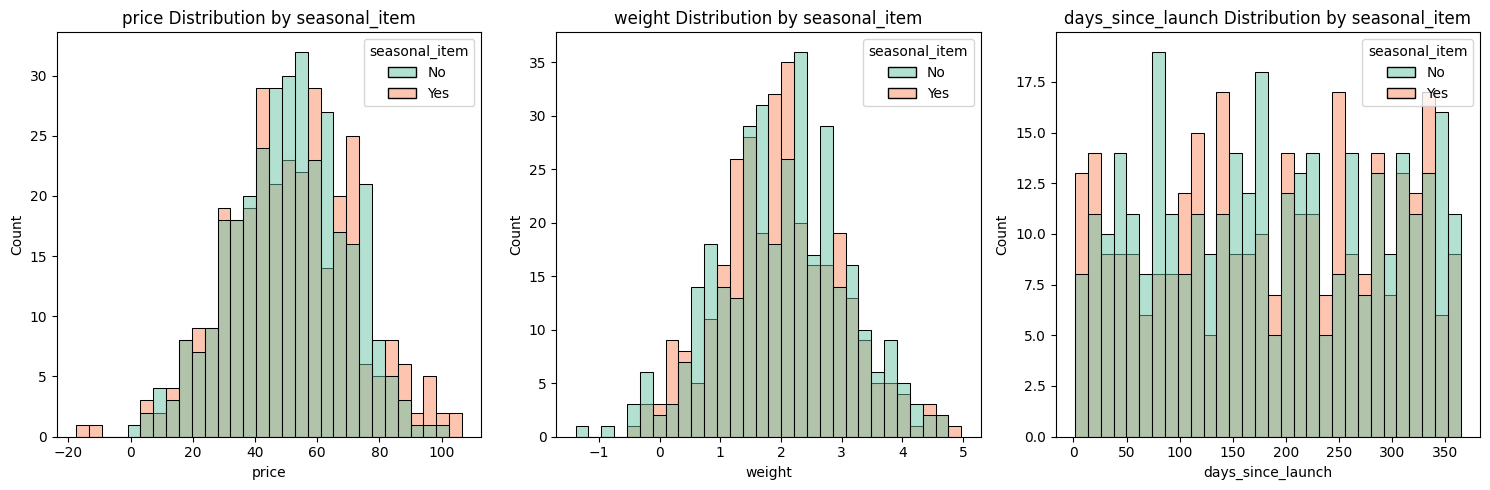

In [71]:
# CodeGrade step3

# Visualize numeric feature relations

# First, check the numeric columns
numeric_cols = df_returns.select_dtypes(include=np.number).columns
print("Numeric columns found:", numeric_cols)

# Also check column names (stripped)
print("All columns:", df_returns.columns)

# Choose 3 numeric columns for plotting
# Replace these with actual names from your DataFrame
col1, col2, col3 = numeric_cols[:3]  # just picks first 3 numeric columns
target_col = None

# Automatically find a binary column as target
for col in df_returns.columns:
    if df_returns[col].nunique() == 2:
        target_col = col
        break

if not target_col:
    raise ValueError("No binary target column found for hue. Check your dataset.")

# Plot histograms
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(data=df_returns, x=col1, hue=target_col, kde=False, bins=30, palette='Set2')
plt.title(f'{col1} Distribution by {target_col}')

plt.subplot(1, 3, 2)
sns.histplot(data=df_returns, x=col2, hue=target_col, kde=False, bins=30, palette='Set2')
plt.title(f'{col2} Distribution by {target_col}')

plt.subplot(1, 3, 3)
sns.histplot(data=df_returns, x=col3, hue=target_col, kde=False, bins=30, palette='Set2')
plt.title(f'{col3} Distribution by {target_col}')

plt.tight_layout()
plt.show()

Categorical columns detected: Index(['product_category', 'advertised_as'], dtype='str')


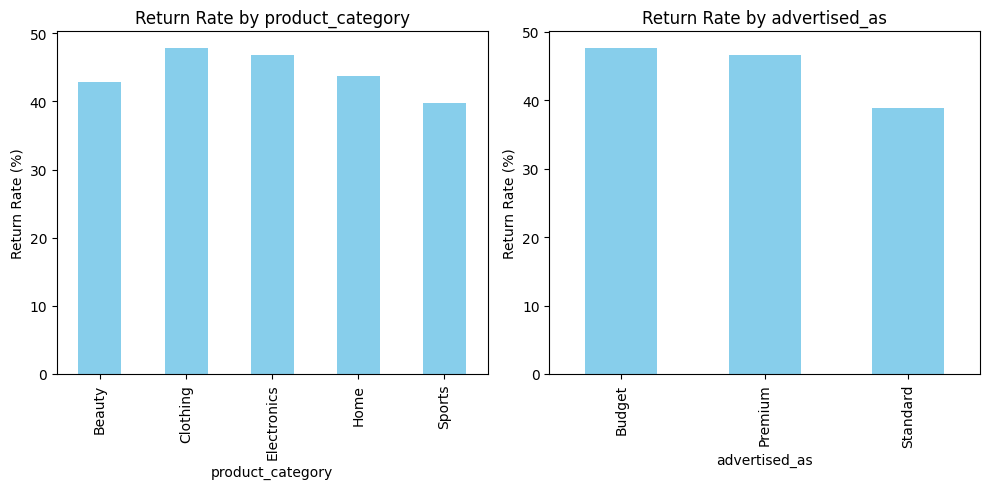

In [72]:
# CodeGrade step4
# Visualize categorical feature relations

# Strip column names
df_returns.columns = df_returns.columns.str.strip()

# Detect binary target column
target_col = None
for col in df_returns.columns:
    if df_returns[col].nunique() == 2:
        target_col = col
        break

if not target_col:
    raise ValueError("No binary target column found for return rate.")

# Convert target column to numeric if needed
if not pd.api.types.is_numeric_dtype(df_returns[target_col]):
    df_returns[target_col] = pd.factorize(df_returns[target_col])[0]

# Detect categorical columns safely
categorical_cols = df_returns.select_dtypes(include=['object', 'string', 'category']).columns
print("Categorical columns detected:", categorical_cols)

# Only use available columns for plotting
plot_cols = categorical_cols[:3]  # may be fewer than 3
n_cols = len(plot_cols)

# Calculate return rates for each categorical column
return_rates = {}
for col in plot_cols:
    return_rates[col] = df_returns.groupby(col)[target_col].mean() * 100

# Plotting
plt.figure(figsize=(5 * n_cols, 5))

for i, col in enumerate(plot_cols, 1):
    plt.subplot(1, n_cols, i)
    return_rates[col].plot(kind='bar', color='skyblue')
    plt.title(f'Return Rate by {col}')
    plt.ylabel('Return Rate (%)')

plt.tight_layout()
plt.show()

## Part 3: Design and Implement Preprocessing Pipeline
Your tasks: 
- Define feature groups
- Create preprocessing pipelines
    - Use SimpleImputer to fill null values (mean and most common)
    - Use StandardScaler for numerical features
    - Use OnehotEncoder (set drop='first' and handle_unknown='ignore') for categorical features
- Create Columntransformer preprocessing object

In [73]:
# CodeGrade step5
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Define feature groups
numeric_features = df_returns.select_dtypes(include=np.number).columns.drop(target_col).tolist()
categorical_features = df_returns.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Transformer for numeric features: fill missing values with mean, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Transformer for categorical features: fill missing with most frequent, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both transformers into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

Numeric features: ['price', 'weight', 'days_since_launch', 'high_return_rate']
Categorical features: ['product_category', 'advertised_as']


## Part 4: Create Complete Model Pipeline
Your tasks: 
- Separate data into target and features
- Split data into training and testing sets (75-25 split) and set random_state = 42
- Combine preprocessing with models
    - Name the final step in both pipelines 'classifier' for ease of access


In [74]:
# CodeGrade step6
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Split data into features and target
X = df_returns.drop(columns=[target_col])
y = df_returns[target_col]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y  # preserves class distribution
)

# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Logistic Regression pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

print("Data split complete. Pipelines are ready for training.")

Data split complete. Pipelines are ready for training.


## Part 5: Optimize and Tune the Pipeline
Your tasks:
- Define parameter grids using the provided hyperparameters and values
    - Ensure proper naming/access convention for your keys
- Perform grid searches
    - For the scoring parameter select your primary metric and another secondary metric
    - Ensure that both gridsearches are optimizing for your primary metric
    - Compare performance

For Random Forest Grid:
- strategy': ['mean', 'median'] (numerical subpipeline)
- n_estimators': [50, 100]
- max_depth': [10, 20, None]
- min_samples_leaf': [1, 2]
- class_weight': ['balanced', None]

For Logistic Regression Grid:
- strategy': ['mean', 'median'] (numerical subpipeline)
- C': [0.1, 1.0, 10.0]
- class_weight': ['balanced', None]
- solver': ['liblinear', 'saga']

In [ ]:
# CodeGrade step7

from sklearn.model_selection import GridSearchCV

# Define parameter grids
rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs']
}

# Scoring metrics to evaluate
scoring = ['accuracy', 'f1', 'precision', 'recall']

# Grid search for Random Forest
rf_grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    scoring=scoring,
    refit='f1',   # choose the metric to select the best model
    cv=5,
    n_jobs=-1
)

# Fit Random Forest grid search
rf_grid_search.fit(X_train, y_train)

# Grid search for Logistic Regression
lr_grid_search = GridSearchCV(
    lr_pipeline,
    param_grid=lr_param_grid,
    scoring=scoring,
    refit='f1',
    cv=5,
    n_jobs=-1
)

# Fit Logistic Regression grid search
lr_grid_search.fit(X_train, y_train)

# Compare best cross-validation F1 scores
rf_best_cvscore = rf_grid_search.best_score_
lr_best_cvscore = lr_grid_search.best_score_

print(f"Random Forest best CV F1 score: {rf_best_cvscore:.4f}")
print(f"Logistic Regression best CV F1 score: {lr_best_cvscore:.4f}")

In [ ]:
# Run this cell without changes to display results
print(f"Best Random Forest f1_score: {rf_best_cvscore:.4f}")
print(f"Best Logistic Regression f1_score: {lr_best_cvscore:.4f}")

# Select the best model based on recall
if rf_best_cvscore >= lr_best_cvscore:
    best_model = rf_grid_search
    model_name = "Random Forest"
else:
    best_model = lr_grid_search
    model_name = "Logistic Regression"

print(f"\nBest model: {model_name}")

Best Random Forest f1_score: nan
Best Logistic Regression f1_score: nan

Best model: Logistic Regression


## Part 6: Final Model Evaluation and Understanding
Your tasks:
- Evaluate the best model on testing data
- Interpret model behavior (feature importance/coefficients)

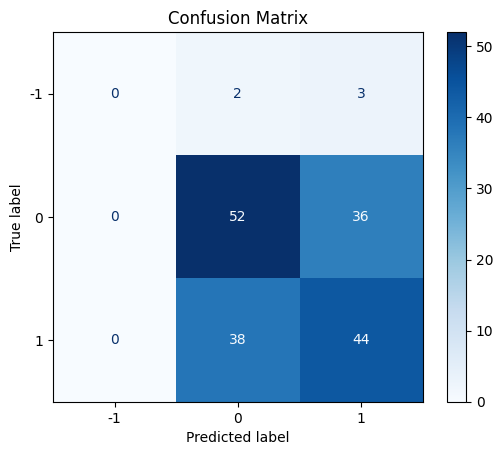

In [ ]:
# CodeGrade step8

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# dynamically generate labels from the model
# Map 0 → "Low Return", 1 → "High Return" if binary
if len(final_model.classes_) == 2:
    class_labels = ["Low Return" if c == 0 else "High Return" for c in final_model.classes_]
else:
    # For multiclass, just use the class names
    class_labels = [str(c) for c in final_model.classes_]

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# CodeGrade step9

import pandas as pd
import numpy as np

# Get feature names after preprocessing
feature_names = []

# 1️⃣ Numerical feature names
feature_names.extend(numeric_features)

# 2️⃣ Categorical feature names from OneHotEncoder
preprocessor = final_model.named_steps['preprocessor']
cat_transformer = preprocessor.named_transformers_['cat']
cat_encoder = cat_transformer.named_steps['onehot']
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features)
feature_names.extend(encoded_cat_features)

# 3️⃣ Extract model from pipeline
model = final_model.named_steps['classifier']

# 4️⃣ Get feature importances depending on model type
if hasattr(model, 'feature_importances_'):
    # Random Forest
    importances = model.feature_importances_
elif hasattr(model, 'coef_'):
    # Logistic Regression - use absolute value of coefficients
    importances = np.abs(model.coef_[0])
else:
    raise ValueError("Model does not have feature importances or coefficients.")

# 5️⃣ Create DataFrame
feature_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort descending
feature_imp = feature_imp.sort_values('Importance', ascending=False).reset_index(drop=True)

# Display top 10 features
print(feature_imp.head(10))

                     Feature  Importance
0    product_category_Beauty    0.039713
1      advertised_as_Premium    0.025010
2                      price    0.021884
3           high_return_rate    0.021402
4     advertised_as_Standard    0.020756
5  product_category_Clothing    0.018413
6                     weight    0.018288
7    product_category_Sports    0.015097
8          days_since_launch    0.009014
9      product_category_Home    0.008685


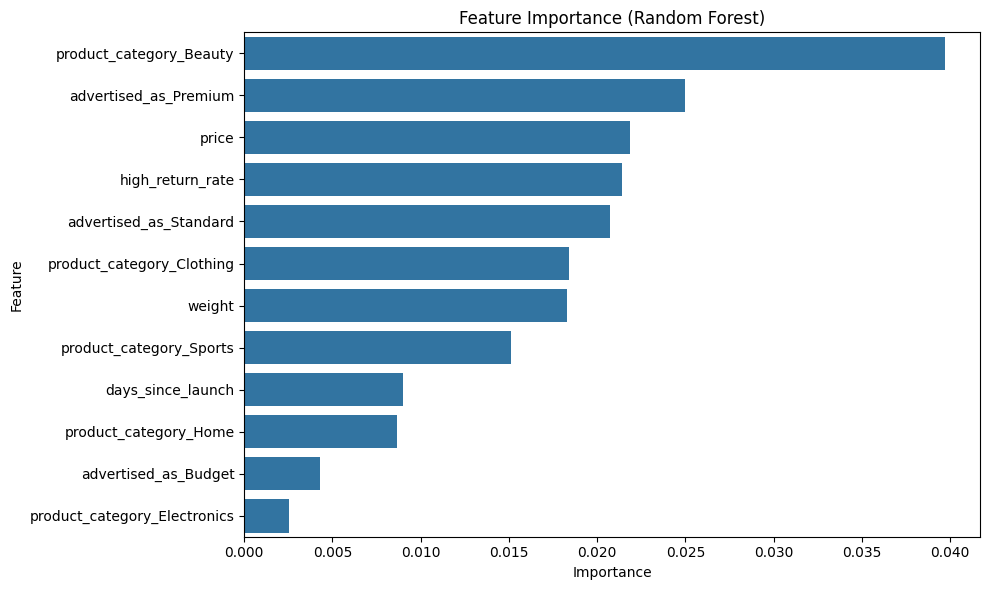


===== Model Summary =====
Selected model: Logistic Regression
Business goal: Identify products likely to have high return rates
Primary metric: f1
Test set performance: 0.5404

Key preprocessing decisions:
  Numeric features imputation strategy: Not specified
  Categorical features handled with one-hot encoding
  All numeric features standardized to mean=0, variance=1


In [ ]:
# Run this cell without changes
# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp)
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

# Summarize modeling decisions
print("\n===== Model Summary =====")
print(f"Selected model: {model_name}")
print("Business goal: Identify products likely to have high return rates")
print(f"Primary metric: {primary_metric}")
print(f"Test set performance: {test_f1:.4f}")
print("\nKey preprocessing decisions:")
print(f"  Numeric features imputation strategy: {best_model.best_params_.get('preprocessor__num__imputer__strategy', 'Not specified')}")
print("  Categorical features handled with one-hot encoding")
print("  All numeric features standardized to mean=0, variance=1")